Imports & Device

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

from sequence_dataset import VideoSequenceDataset
from dataset_and_transforms import val_transforms


Load Validation & Test Datasets

In [2]:
SEQ_LEN = 10
BATCH_SIZE = 2

val_dataset = VideoSequenceDataset(
    metadata_csv="dataset/processed/metadata_val.csv",
    transform=val_transforms,
    seq_len=SEQ_LEN
)

test_dataset = VideoSequenceDataset(
    metadata_csv="dataset/processed/metadata_test.csv",
    transform=val_transforms,
    seq_len=SEQ_LEN
)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Validation videos:", len(val_dataset))
print("Test videos:", len(test_dataset))


Validation videos: 75
Test videos: 75


Load Trained Model

In [3]:
from torchvision import models

class CNN_LSTM(nn.Module):
    def __init__(self, hidden_dim=256, num_classes=2):
        super(CNN_LSTM, self).__init__()

        resnet = models.resnet50(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])
        self.feature_dim = 2048

        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        batch, seq_len, c, h, w = x.shape
        features = []

        for t in range(seq_len):
            f = self.cnn(x[:, t])
            f = f.view(batch, -1)
            features.append(f)

        features = torch.stack(features, dim=1)
        lstm_out, _ = self.lstm(features)
        out = self.fc(lstm_out[:, -1])
        return out


device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN_LSTM().to(device)
model.load_state_dict(torch.load("model2_cnn_lstm.pth"))
model.eval()

print("Model loaded successfully")


C:\Users\pratik\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\pratik\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model loaded successfully


Evaluation Function

In [4]:
def evaluate_model(model, loader):
    y_true = []
    y_pred = []

    with torch.no_grad():
        for sequences, labels in loader:
            sequences = sequences.to(device)
            outputs = model(sequences)

            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    return np.array(y_true), np.array(y_pred)


Validate the Model

In [5]:
y_val_true, y_val_pred = evaluate_model(model, val_loader)

print("VALIDATION RESULTS")
print(classification_report(y_val_true, y_val_pred))


VALIDATION RESULTS
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        38

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



Test the Model

In [6]:
y_test_true, y_test_pred = evaluate_model(model, test_loader)

print("TEST RESULTS")
print(classification_report(y_test_true, y_test_pred))


TEST RESULTS
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        37
           1       0.97      1.00      0.99        38

    accuracy                           0.99        75
   macro avg       0.99      0.99      0.99        75
weighted avg       0.99      0.99      0.99        75



Confusion Matrix (Test Set)

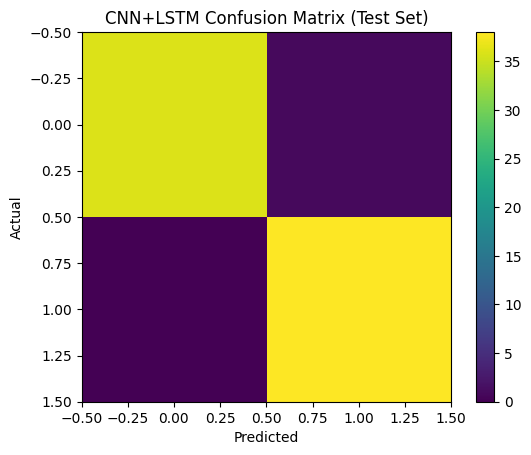

In [7]:
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure()
plt.imshow(cm)
plt.title("CNN+LSTM Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()
